In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)

print("Using device:", device)

Using device: cuda


In [2]:
tf = transforms.ToTensor()

cifar_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=tf
)

image, label = cifar_train[0]

# Add batch dimension: (3, 32, 32) -> (1, 3, 32, 32)
image_batch = image.unsqueeze(0)

print("Image shape:", image_batch.shape)
print("Label:", label)

100.0%


Image shape: torch.Size([1, 3, 32, 32])
Label: 6


c:\Users\Baku\anaconda3\envs\torch_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
vertical_kernel = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32)

horizontal_kernel = vertical_kernel.T

blur_kernel = torch.ones((3, 3), dtype=torch.float32) / 9

In [4]:
def make_filter(kernel):
    conv = nn.Conv2d(
        in_channels=3,
        out_channels=1,
        kernel_size=3,
        padding=1,
        bias=False
    )

    with torch.no_grad():
        # Same 3x3 filter is applied to all 3 RGB channels
        conv.weight[:] = kernel.view(1, 1, 3, 3).repeat(1, 3, 1, 1)

    return conv


vertical_filter = make_filter(vertical_kernel)
horizontal_filter = make_filter(horizontal_kernel)
blur_filter = make_filter(blur_kernel)

with torch.no_grad():
    vertical_output = vertical_filter(image_batch)
    horizontal_output = horizontal_filter(image_batch)
    blur_output = blur_filter(image_batch)

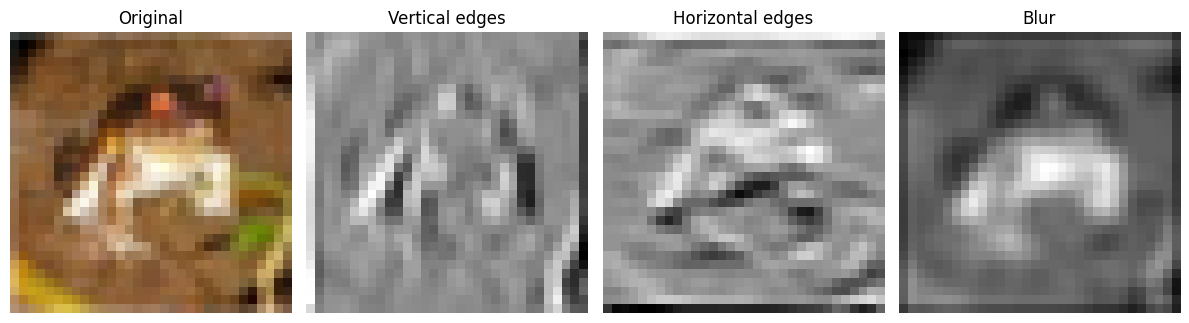

In [5]:
original_img = image.permute(1, 2, 0).numpy()

vertical_img = vertical_output.squeeze().numpy()
horizontal_img = horizontal_output.squeeze().numpy()
blur_img = blur_output.squeeze().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(vertical_img, cmap="gray")
plt.title("Vertical edges")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(horizontal_img, cmap="gray")
plt.title("Horizontal edges")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blur_img, cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

The vertical edge detector highlights areas where pixel values change strongly from left to right, so it reacts to vertical boundaries. The horizontal edge detector highlights areas where pixel values change strongly from top to bottom, so it reacts to horizontal boundaries. The blur filter averages neighbouring pixels, which smooths the image and reduces sharp detail.

In [6]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)


tiny_cnn = TinyCNN()

x = torch.randn(8, 3, 32, 32)

print("Input:", x.shape)

x1 = tiny_cnn.conv1(x)
print("After conv1:", x1.shape)

x2 = tiny_cnn.pool1(x1)
print("After pool1:", x2.shape)

x3 = tiny_cnn.conv2(x2)
print("After conv2:", x3.shape)

x4 = tiny_cnn.pool2(x3)
print("After pool2:", x4.shape)

Input: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

## Task 2

In [7]:
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=tf
)

val_set = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=tf
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)

print("Train samples:", len(train_set))
print("Validation samples:", len(val_set))

Train samples: 50000
Validation samples: 10000


In [8]:
class CIFARSmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CIFARSmallCNN().to(device)

print(model)

CIFARSmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequ

In [9]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 1117354
Trainable parameters: 1117354


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [11]:
epochs = 15

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 1.4414 | Val Loss: 1.1462 | Train Acc: 0.4753 | Val Acc: 0.5808
Epoch 02/15 | Train Loss: 0.9917 | Val Loss: 0.8763 | Train Acc: 0.6463 | Val Acc: 0.6960
Epoch 03/15 | Train Loss: 0.8413 | Val Loss: 0.7719 | Train Acc: 0.7046 | Val Acc: 0.7265
Epoch 04/15 | Train Loss: 0.7421 | Val Loss: 0.7123 | Train Acc: 0.7392 | Val Acc: 0.7440
Epoch 05/15 | Train Loss: 0.6760 | Val Loss: 0.6969 | Train Acc: 0.7601 | Val Acc: 0.7624
Epoch 06/15 | Train Loss: 0.6225 | Val Loss: 0.6749 | Train Acc: 0.7799 | Val Acc: 0.7622
Epoch 07/15 | Train Loss: 0.5743 | Val Loss: 0.6819 | Train Acc: 0.7981 | Val Acc: 0.7693
Epoch 08/15 | Train Loss: 0.5365 | Val Loss: 0.6673 | Train Acc: 0.8087 | Val Acc: 0.7734
Epoch 09/15 | Train Loss: 0.5021 | Val Loss: 0.6078 | Train Acc: 0.8223 | Val Acc: 0.7933
Epoch 10/15 | Train Loss: 0.4612 | Val Loss: 0.6336 | Train Acc: 0.8348 | Val Acc: 0.7834
Epoch 11/15 | Train Loss: 0.4239 | Val Loss: 0.6064 | Train Acc: 0.8472 | Val Acc: 0.7953
Epoch 12/1

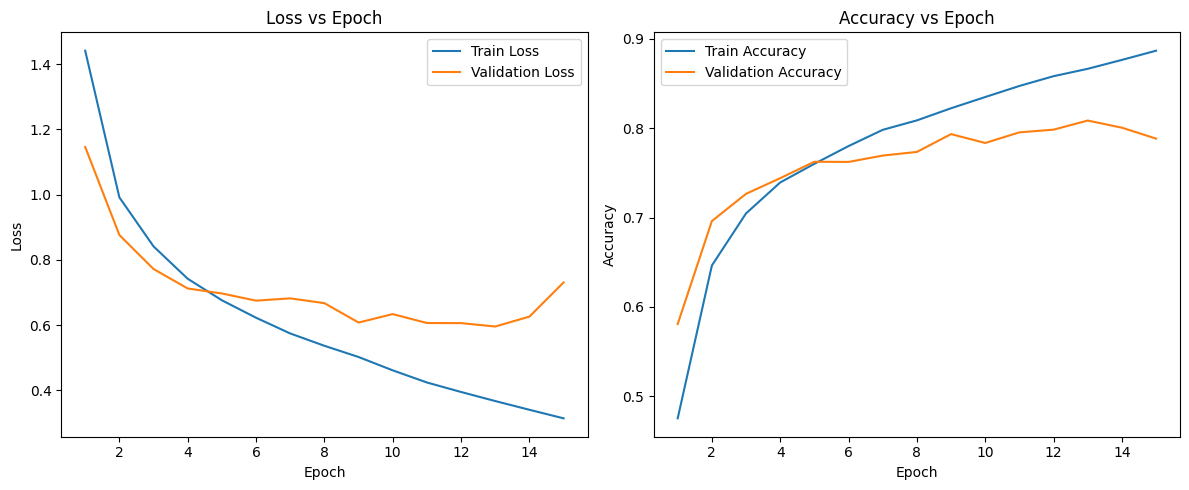

Best validation accuracy: 0.8085
Best epoch: 13


In [12]:
epoch_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, train_losses, label="Train Loss")
plt.plot(epoch_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, train_accs, label="Train Accuracy")
plt.plot(epoch_range, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best epoch: {best_epoch}")

In [13]:
task2_best_val_acc = max(val_accs)
task2_best_epoch = val_accs.index(task2_best_val_acc) + 1

task2_train_acc_at_best = train_accs[task2_best_epoch - 1]
task2_val_acc_at_best = val_accs[task2_best_epoch - 1]
task2_gap = task2_train_acc_at_best - task2_val_acc_at_best

print(f"Task 2 best val accuracy: {task2_best_val_acc:.4f}")
print(f"Task 2 best epoch: {task2_best_epoch}")
print(f"Task 2 train/val gap: {task2_gap:.4f}")

Task 2 best val accuracy: 0.8085
Task 2 best epoch: 13
Task 2 train/val gap: 0.0579


In [14]:
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

aug_train_set = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_tf
)

aug_val_set = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_tf
)

aug_train_loader = DataLoader(aug_train_set, batch_size=128, shuffle=True)
aug_val_loader = DataLoader(aug_val_set, batch_size=128, shuffle=False)

print("Augmented train samples:", len(aug_train_set))
print("Validation samples:", len(aug_val_set))

Augmented train samples: 50000
Validation samples: 10000


In [15]:
aug_model = CIFARSmallCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(aug_model.parameters(), lr=1e-3)

print(aug_model)

CIFARSmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequ

In [16]:
epochs = 15

aug_train_losses = []
aug_val_losses = []
aug_train_accs = []
aug_val_accs = []

for epoch in range(epochs):
    aug_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in aug_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = aug_model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate(aug_model, aug_val_loader, criterion, device)

    aug_train_losses.append(train_loss)
    aug_val_losses.append(val_loss)
    aug_train_accs.append(train_acc)
    aug_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 1.6140 | Val Loss: 1.1927 | Train Acc: 0.4045 | Val Acc: 0.5741
Epoch 02/15 | Train Loss: 1.2285 | Val Loss: 1.0049 | Train Acc: 0.5582 | Val Acc: 0.6396
Epoch 03/15 | Train Loss: 1.0622 | Val Loss: 1.0237 | Train Acc: 0.6210 | Val Acc: 0.6488
Epoch 04/15 | Train Loss: 0.9718 | Val Loss: 0.8394 | Train Acc: 0.6555 | Val Acc: 0.6997
Epoch 05/15 | Train Loss: 0.9094 | Val Loss: 0.8129 | Train Acc: 0.6789 | Val Acc: 0.7042
Epoch 06/15 | Train Loss: 0.8656 | Val Loss: 0.7177 | Train Acc: 0.6970 | Val Acc: 0.7455
Epoch 07/15 | Train Loss: 0.8290 | Val Loss: 0.7096 | Train Acc: 0.7074 | Val Acc: 0.7520
Epoch 08/15 | Train Loss: 0.7939 | Val Loss: 0.6427 | Train Acc: 0.7217 | Val Acc: 0.7772
Epoch 09/15 | Train Loss: 0.7700 | Val Loss: 0.6613 | Train Acc: 0.7312 | Val Acc: 0.7681
Epoch 10/15 | Train Loss: 0.7481 | Val Loss: 0.6384 | Train Acc: 0.7396 | Val Acc: 0.7777
Epoch 11/15 | Train Loss: 0.7216 | Val Loss: 0.7570 | Train Acc: 0.7488 | Val Acc: 0.7440
Epoch 12/1

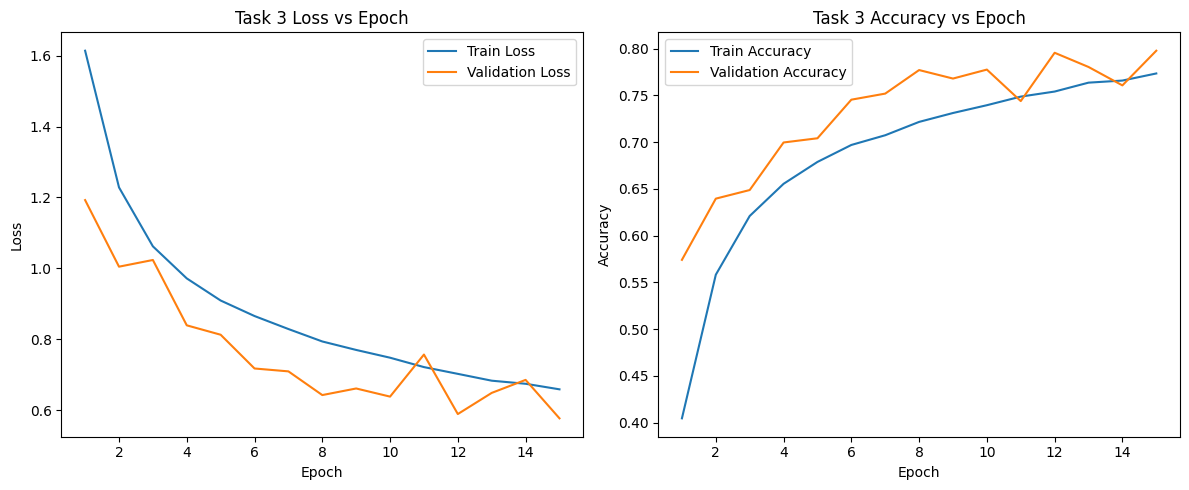

In [17]:
epoch_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, aug_train_losses, label="Train Loss")
plt.plot(epoch_range, aug_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 3 Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, aug_train_accs, label="Train Accuracy")
plt.plot(epoch_range, aug_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 3 Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
task3_best_val_acc = max(aug_val_accs)
task3_best_epoch = aug_val_accs.index(task3_best_val_acc) + 1

task3_train_acc_at_best = aug_train_accs[task3_best_epoch - 1]
task3_val_acc_at_best = aug_val_accs[task3_best_epoch - 1]
task3_gap = task3_train_acc_at_best - task3_val_acc_at_best

print(f"Task 3 best val accuracy: {task3_best_val_acc:.4f}")
print(f"Task 3 best epoch: {task3_best_epoch}")
print(f"Task 3 train/val gap: {task3_gap:.4f}")

Task 3 best val accuracy: 0.7979
Task 3 best epoch: 15
Task 3 train/val gap: -0.0243


In [19]:
comparison = {
    "Run": ["Task 2 (no augmentation)", "Task 3 (with augmentation)"],
    "Best val accuracy": [task2_best_val_acc, task3_best_val_acc],
    "Train/val gap": [task2_gap, task3_gap]
}

comparison

{'Run': ['Task 2 (no augmentation)', 'Task 3 (with augmentation)'],
 'Best val accuracy': [0.8085, 0.7979],
 'Train/val gap': [0.05789999999999995, -0.02434000000000003]}